<a href="https://colab.research.google.com/github/pragnyavaleti/2520030238_ML/blob/main/Pratical/Decision_Tree_with_depts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
# Decision Tree with depthlimit, etc.. Attributes.
# Decision Tree - Iris Dataset Classification
# Binary Classification
# Gini vs Entropy + Max Depth

# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [31]:
import pandas as pd

# Step 2: Load Placement Prediction Dataset

df = pd.read_csv('/content/placement_predict_50k Dataset_final.csv')

X = df.drop(columns=['PlacementStatus'])
y = df['PlacementStatus']
# Convert categorical columns into numbers
X = pd.get_dummies(X, drop_first=True)

print("Dataset Shape:", X.shape)
print("Features:", X.columns)
print("Dataset Shape:", X.shape)
print("Classes:", y.unique())

Dataset Shape: (50000, 47)
Features: Index(['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4',
       'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA',
       'AttendancePercent', 'Internships', 'Projects', 'Workshops',
       'Certifications', 'Publications', 'AptitudeTestScore',
       'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore',
       'ExtraCurricular', 'IsAnomaly', 'Salary Package', 'Gender_Male',
       'City_Bangalore', 'City_Chennai', 'City_Delhi', 'City_Hyderabad',
       'City_Jaipur', 'City_Kochi', 'City_Kolkata', 'City_Mumbai', 'City_Pune',
       'CollegeTier_Tier2', 'CollegeTier_Tier3', 'Stream_Civil', 'Stream_ECE',
       'Stream_EE', 'Stream_IT', 'Stream_Mechanical',
       'Specialisation_DataScience', 'Specialisation_Embedded',
       'Specialisation_Networking', 'Hostel_Yes', 'HistoryOfBacklogs_Yes',
       'CGPA_Tier_Low', 'CGPA_Tier_Mid'],
      dtype='object')
Dataset Shape: (50000, 47)
Classes: [0 1]


In [32]:
# Step 3: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



===== GINI DECISION TREE =====
Accuracy: 0.9982

Confusion Matrix:
[[3411   18]
 [   0 6571]]

Classification Report:
              precision    recall  f1-score   support

  Not Placed       1.00      0.99      1.00      3429
      Placed       1.00      1.00      1.00      6571

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



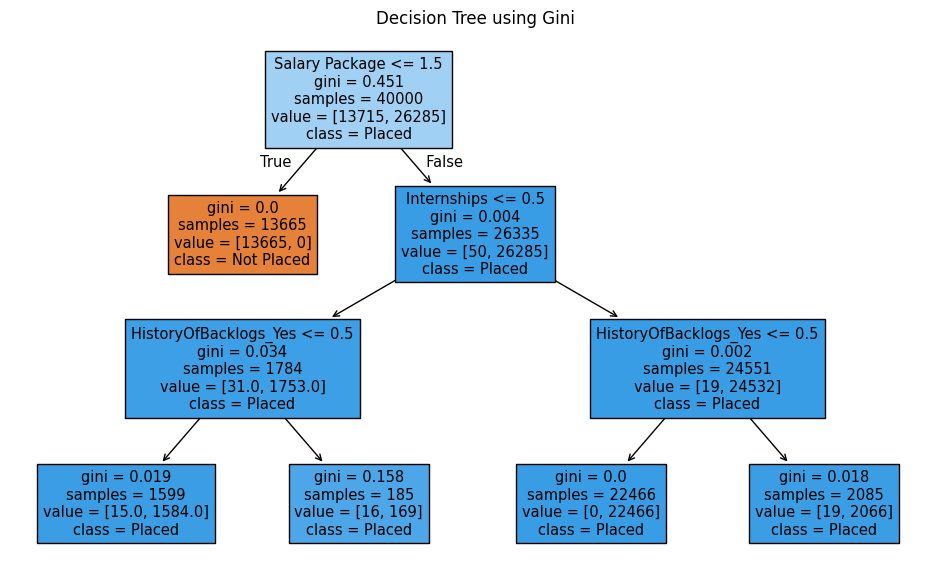

In [33]:
# Step 4: Decision Tree using Gini
# ==========================================================

gini_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

gini_model.fit(X_train, y_train)

y_pred_gini = gini_model.predict(X_test)

print("\n===== GINI DECISION TREE =====")

print("Accuracy:", accuracy_score(y_test, y_pred_gini))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gini))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_gini,
    target_names=["Not Placed", "Placed"]
))


# Plot Gini Tree
plt.figure(figsize=(12, 7))

plot_tree(
    gini_model,
    feature_names=X.columns,
    class_names=["Not Placed", "Placed"],
    filled=True
)

plt.title("Decision Tree using Gini")
plt.show()


===== ENTROPY DECISION TREE =====
Accuracy: 0.9982

Confusion Matrix:
[[3411   18]
 [   0 6571]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3429
           1       1.00      1.00      1.00      6571

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



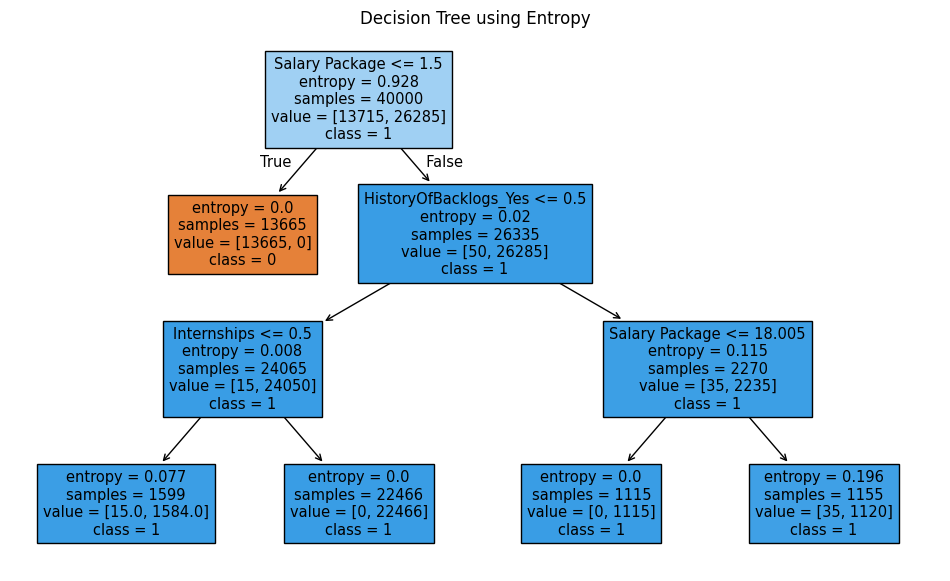

In [34]:
# Step 5: Decision Tree using Entropy
# ==========================================================

entropy_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

entropy_model.fit(X_train, y_train)

y_pred_entropy = entropy_model.predict(X_test)

print("\n===== ENTROPY DECISION TREE =====")

print("Accuracy:", accuracy_score(y_test, y_pred_entropy))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_entropy))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_entropy
))


# Plot Entropy Tree
plt.figure(figsize=(12, 7))

plot_tree(
    entropy_model,
    feature_names=X.columns,
    class_names=[str(c) for c in entropy_model.classes_],
    filled=True
)

plt.title("Decision Tree using Entropy")
plt.show()

In [35]:
# Step 6: Compare Gini and Entropy
# ==========================================================

gini_accuracy = accuracy_score(y_test, y_pred_gini)
entropy_accuracy = accuracy_score(y_test, y_pred_entropy)

comparison = pd.DataFrame({
"Criterion": ["Gini", "Entropy"],
"Accuracy": [gini_accuracy, entropy_accuracy]
})

print("\n===== GINI vs ENTROPY =====")
print(comparison)




===== GINI vs ENTROPY =====
  Criterion  Accuracy
0      Gini    0.9982
1   Entropy    0.9982


In [36]:
depth_results = []

for depth in range(1, 11):
    # Gini
    model_gini = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )

    model_gini.fit(X_train, y_train)

    train_acc_gini = model_gini.score(X_train, y_train)
    test_acc_gini = model_gini.score(X_test, y_test)


    # Entropy
    model_entropy = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=42
    )

    model_entropy.fit(X_train, y_train)

    train_acc_entropy = model_entropy.score(X_train, y_train)
    test_acc_entropy = model_entropy.score(X_test, y_test)


    depth_results.append([
        depth,
        train_acc_gini,
        test_acc_gini,
        train_acc_entropy,
        test_acc_entropy
    ])


depth_df = pd.DataFrame(
    depth_results,
    columns=[
        "Max Depth",
        "Gini Train Accuracy",
        "Gini Test Accuracy",
        "Entropy Train Accuracy",
        "Entropy Test Accuracy"
    ]
)

print("\n===== MAX DEPTH RESULTS =====")
print(depth_df)


===== MAX DEPTH RESULTS =====
   Max Depth  Gini Train Accuracy  Gini Test Accuracy  Entropy Train Accuracy  \
0          1             0.998750              0.9982                0.998750   
1          2             0.998750              0.9982                0.998750   
2          3             0.998750              0.9982                0.998750   
3          4             0.998750              0.9982                0.998750   
4          5             0.998775              0.9980                0.998750   
5          6             0.998975              0.9976                0.998800   
6          7             0.999200              0.9976                0.998900   
7          8             0.999300              0.9974                0.999175   
8          9             0.999450              0.9966                0.999300   
9         10             0.999625              0.9969                0.999425   

   Entropy Test Accuracy  
0                 0.9982  
1                 0.998

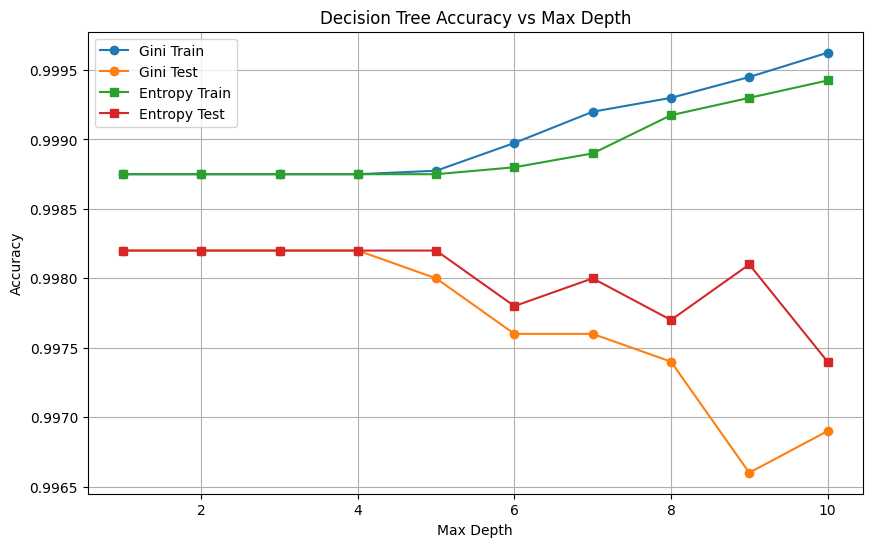

In [37]:
# Step 8: Plot Accuracy vs Max Depth
# ==========================================================

plt.figure(figsize=(10, 6))

plt.plot(
depth_df["Max Depth"],
depth_df["Gini Train Accuracy"],
marker="o",
label="Gini Train"
)

plt.plot(
depth_df["Max Depth"],
depth_df["Gini Test Accuracy"],
marker="o",
label="Gini Test"
)

plt.plot(
depth_df["Max Depth"],
depth_df["Entropy Train Accuracy"],
marker="s",
label="Entropy Train"
)

plt.plot(
depth_df["Max Depth"],
depth_df["Entropy Test Accuracy"],
marker="s",
label="Entropy Test"
)

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs Max Depth")
plt.legend()
plt.grid(True)
plt.show()